In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import seaborn as sns
# import nbimporter
# from main import extract_random_walk_series

### Start of the Pipeline

In [6]:
dtr = pd.read_csv('../results/DTR.csv')
gru= pd.read_csv('../results/GRU.csv')
lgbm = pd.read_csv('../results/LGBM.csv')
lstm = pd.read_csv('../results/LSTM.csv')
mlp = pd.read_csv('../results/MLP.csv')
padt_A = pd.read_csv('../results/PADT-A.csv')
padt_B = pd.read_csv('../results/PADT-B.csv')
rf_padt_B = pd.read_csv('../results/RF_PADT-B.csv')
rf = pd.read_csv('../results/RF.csv')
svr = pd.read_csv('../results/SVR.csv')
xgbr = pd.read_csv('../results/XGBR.csv')

---
##### DATA FRAME

In [7]:
def series_data_by_name(series_name):
    lgbm_model =  lgbm[ (lgbm['series_name'] == series_name)]
    padt_A_model =  padt_A[ (padt_A['series_name'] == series_name)]
    xgbr_model = xgbr[ (xgbr['series_name'] == series_name)]
    svr_model = svr[ (svr['series_name'] == series_name)]
    rf_model = rf[ (rf['series_name'] == series_name)]
    rf_padt_B_model = rf_padt_B[ (rf_padt_B['series_name'] == series_name)]
    padt_B_model = padt_B[ (padt_B['series_name'] == series_name)]
    mlp_model = mlp[ (mlp['series_name'] == series_name)]   
    lstm_model = lstm[ (lstm['series_name'] == series_name)]
    dtr_model = dtr[ (dtr['series_name'] == series_name)]

    models_all = pd.concat([lgbm_model, padt_A_model, xgbr_model, svr_model, rf_model, rf_padt_B_model, padt_B_model, mlp_model, lstm_model, dtr_model], ignore_index=True)
    return models_all

In [8]:
def data_frame(name_model):
    path = f'../results/{name_model}.csv'
    model = pd.read_csv(path)
    return model

def data_frame_a_series(name_model, series_name):
    model = data_frame(name_model)
    model = model[model['series_name'] == series_name]
    return model

def model_list():

    modelos = ["LGBM", "PADT-A", "XGBR", "SVR", "RF", "RF_PADT-B", "PADT-B", "MLP", "LSTM", "DTR"]
    return modelos

def parse_date(x):
    try:
        return pd.to_datetime(x, format="%Y-%m-%d")
    except:
        return pd.to_datetime(x, format="%Y")

def date_serie(name_model, series_name):
    path = f'../../data/clean/others/{series_name}.csv'
    serie = pd.read_csv(path)
    serie["date"] = serie["date"].apply(parse_date)
    df_modelo = data_frame_a_series(name_model, series_name)
    df_modelo = df_modelo.copy()
    df_modelo["date"] = serie.loc[df_modelo["index"], "date"].values
    return df_modelo




---
##### ERROS (AE, SE, APE)

In [9]:
def errors_ae_by_name(series_name):
    lista_erros = []
    models = model_list()

    for model in models:
        df_modelo = data_frame_a_series(model, series_name)
        df_modelo_ae = df_modelo[['AE','Phase', 'model']]
        lista_erros.append(df_modelo_ae)
    
    erros_ae_all = pd.concat(lista_erros, ignore_index=True)
    return erros_ae_all

def errors_se_by_name(series_name):
    lista_erros = []
    models = model_list()

    for model in models:
        df_modelo = data_frame_a_series(model, series_name)
        df_modelo_se = df_modelo[['SE','Phase', 'model']]
        lista_erros.append(df_modelo_se)
    
    erros_se_all = pd.concat(lista_erros, ignore_index=True)
    return erros_se_all

def errors_ape_by_name(series_name):
    lista_erros = []
    models = model_list()

    for model in models:
        df_modelo = data_frame_a_series(model, series_name)
        df_modelo_ape = df_modelo[['APE','Phase', 'model']]
        lista_erros.append(df_modelo_ape)
    
    erros_ape_all = pd.concat(lista_erros, ignore_index=True)
    return erros_ape_all

---
##### PLOT

In [ ]:
def plot_model_erro(series_name):
    models = model_list()
    df_all = errors_ae_by_name(series_name)

    stats = (
        df_all
        .groupby(["model", "Phase"])["AE"]
        .agg(["mean", "std"])
        .reset_index()
    )

    fig, axes = plt.subplots(4, 3, figsize=(18, 14))

    axes = axes.flatten()

    models = stats["model"].unique()

    for i, model in enumerate(models):
        ax = axes[i]

        data_model = stats[stats["model"] == model].copy()

        
        data_model["Phase"] = pd.Categorical(
            data_model["Phase"],
            categories=["train", "val"],
            ordered=True
        )

        data_model = data_model.sort_values("Phase")

        mean = data_model["mean"].values
        std = data_model["std"].fillna(0).values

        x = np.arange(len(mean)) 

        ax.plot(x, mean, marker="o", linewidth=2, label="Mean")

        ax.fill_between(
            x,
            mean - std,
            mean + std,
            alpha=0.2,
            label="Error Range"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(data_model["Phase"])  
        ax.set_title(model)
        ax.set_ylabel("MAE")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

    # remove espaços vazios
    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Model Performance (From DataFrame)", fontsize=14)
    plt.tight_layout()
    plt.show()


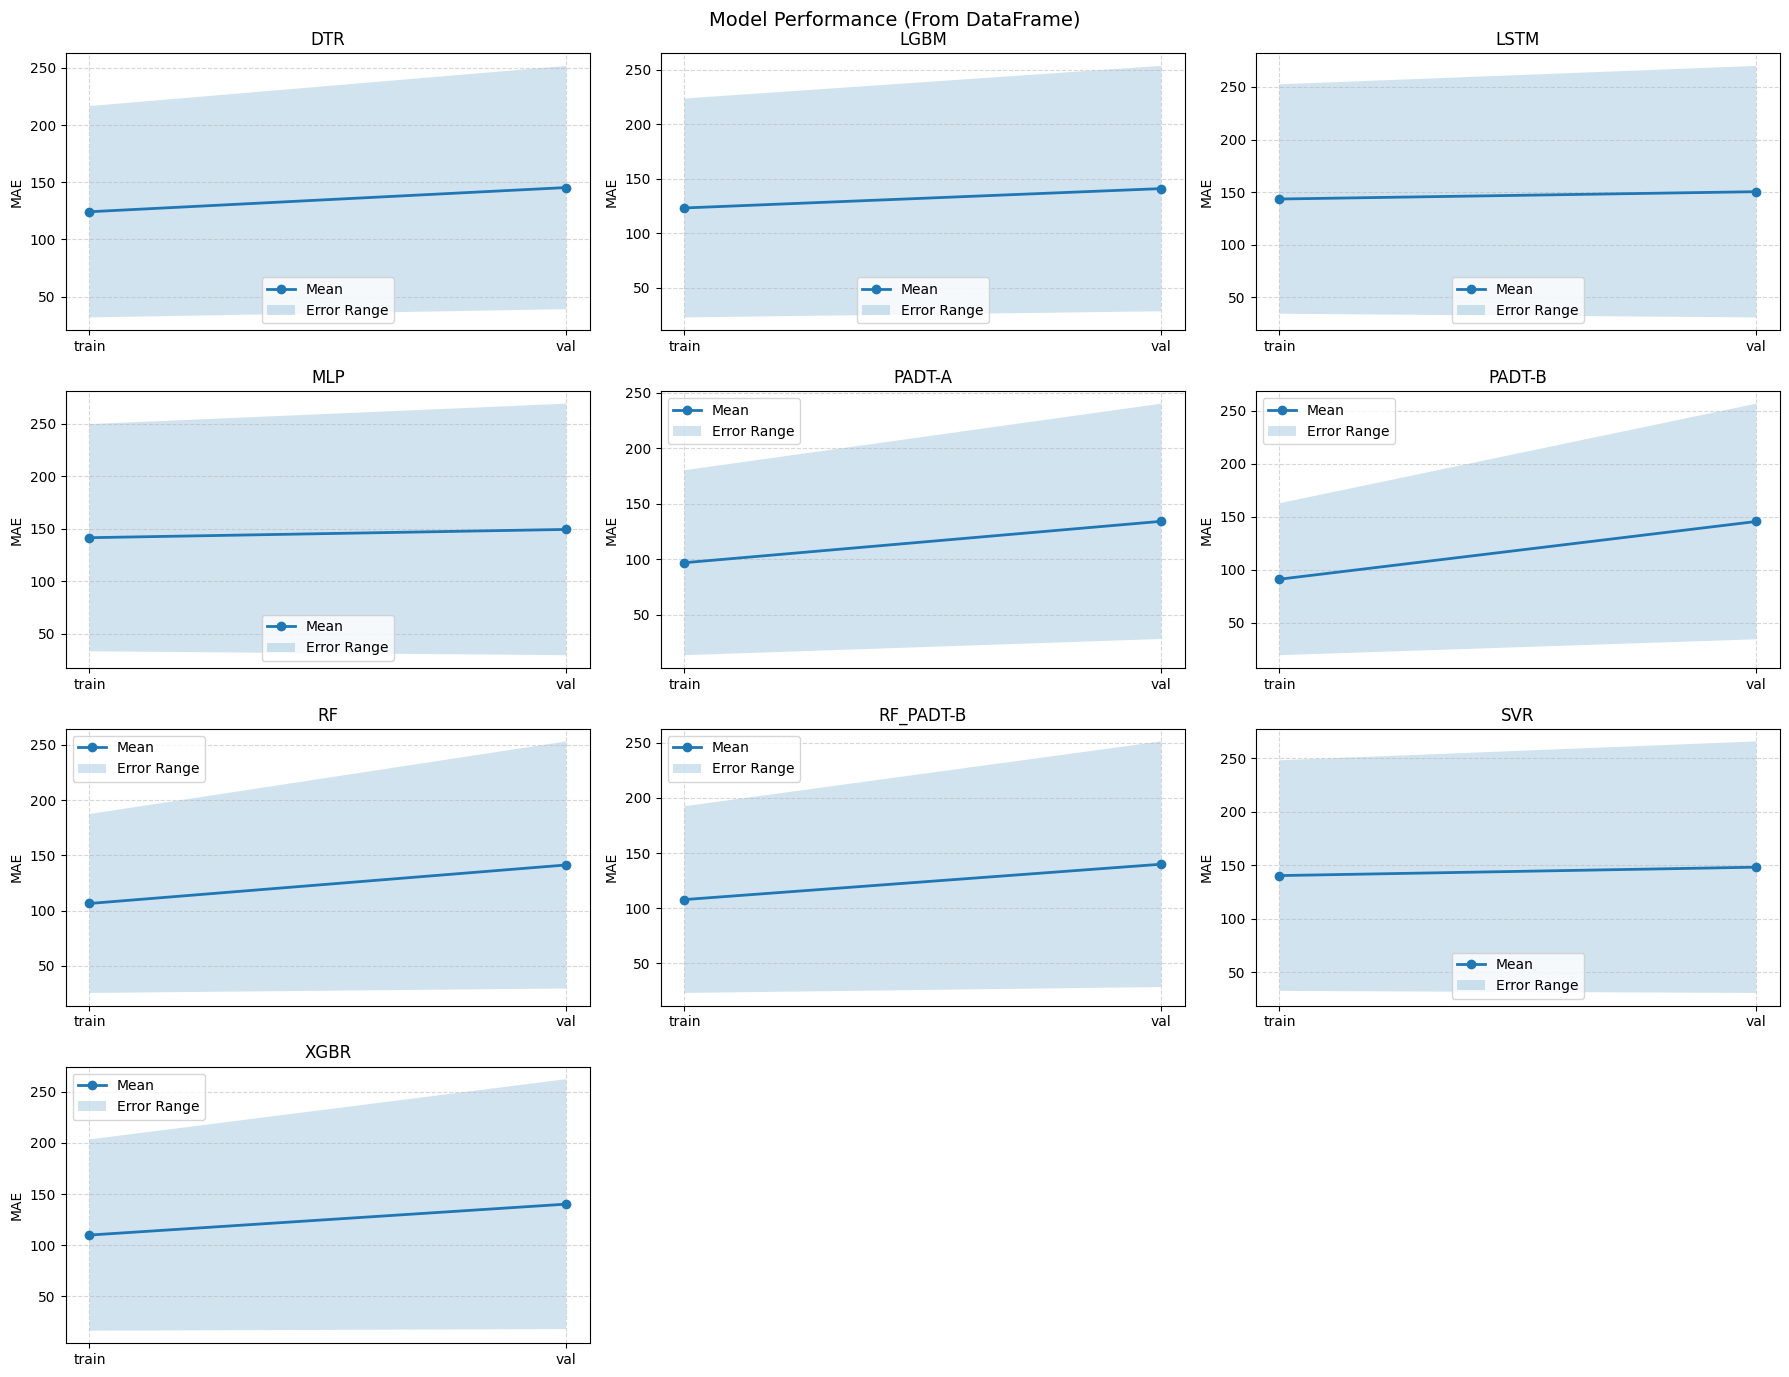

In [ ]:
plot_model('nile')

In [ ]:
def plot_error_distribution(series_name):
    df_all = errors_ae_by_name(series_name)
    plt.figure(figsize=(16, 10))

    g = sns.catplot(
        data=df_all,
        x="Phase",
        y="AE",
        col="model",
        kind="violin",
        col_wrap=4,
        height=4,
        aspect=1,
        palette="Set2",
        inner="box"
    )

    g.fig.suptitle("Absolute Error Distribution by Model", y=1.03)
    g.set_axis_labels("Dataset Split", "Absolute Error")


    plt.title("Error Distribution by Model")
    plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_18032\3705312647.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1600x1000 with 0 Axes>

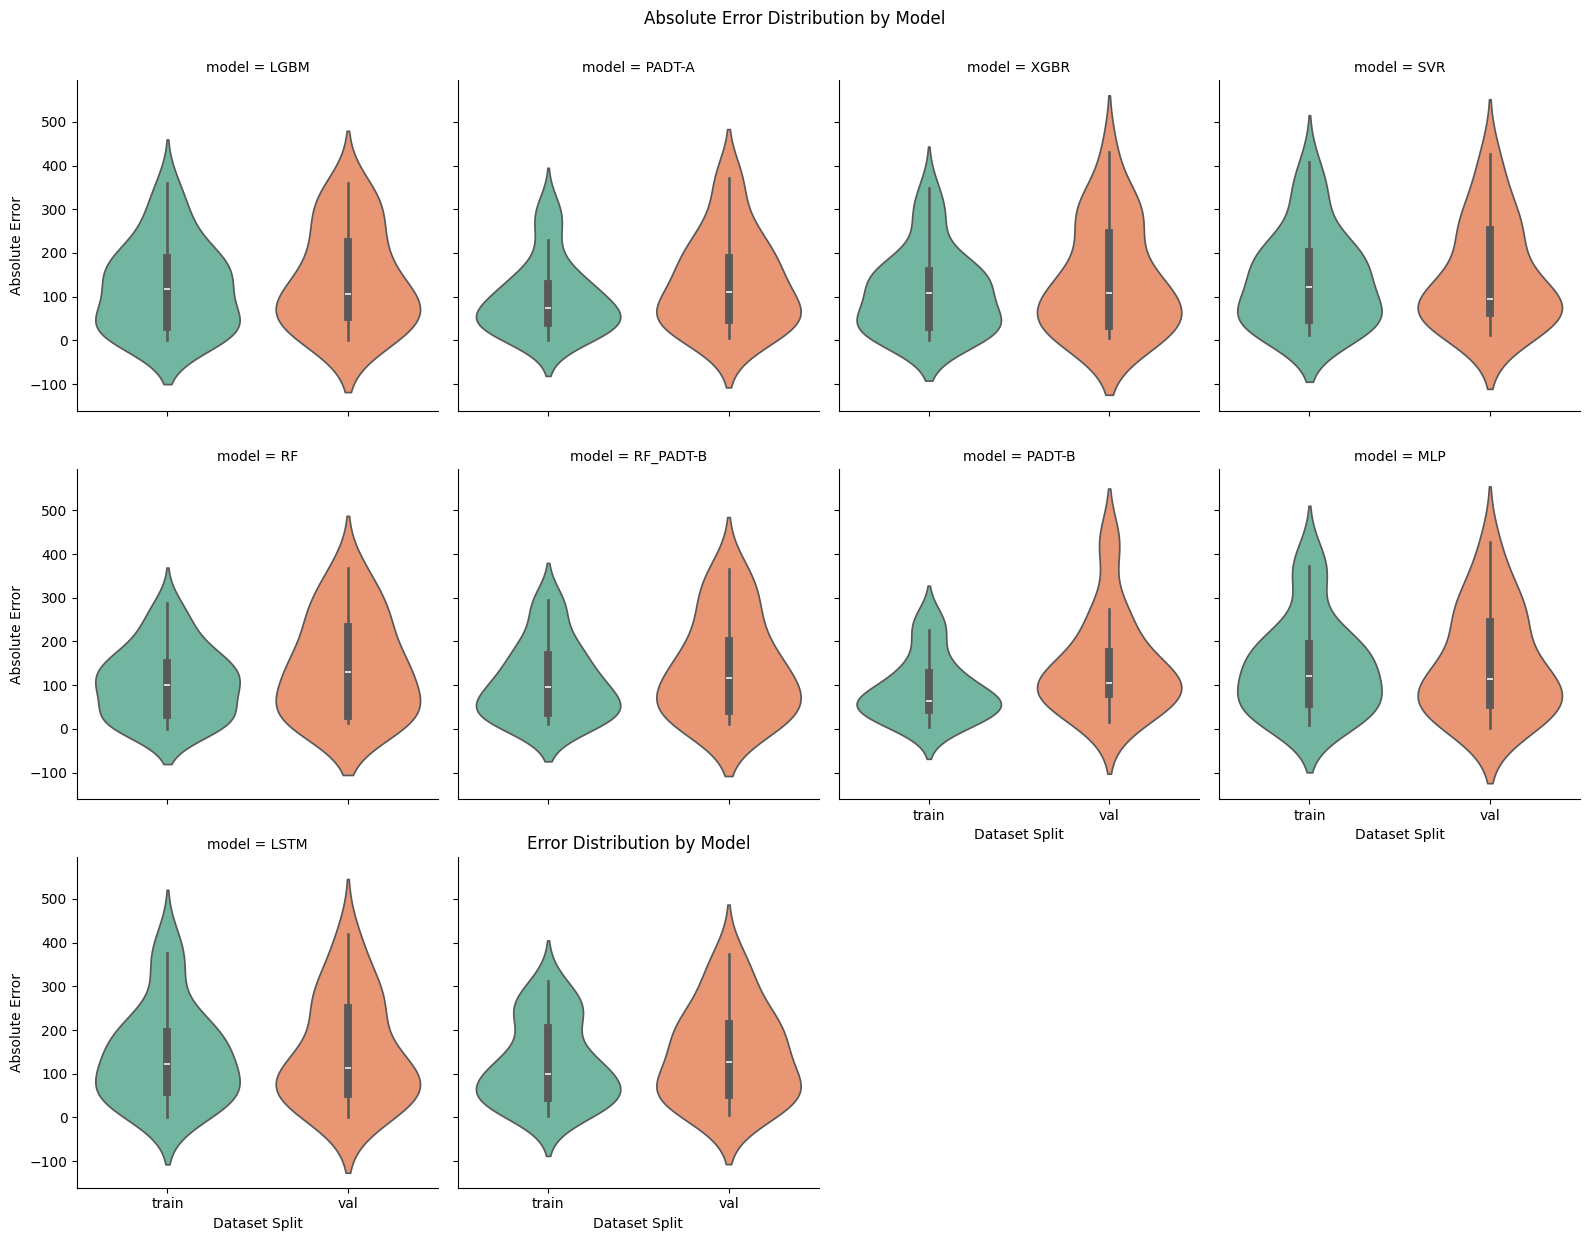

In [ ]:
plot_error_distribution('nile')

In [20]:
def plot_time_series_with_split(series_name):
    plt.figure(figsize=(10, 6))
    fig, axes = plt.subplots(6, 2, figsize=(16, 20))
    axes = axes.flatten()
    models = model_list()

    for i, name_model in enumerate(models):
        df_modelo = data_frame_a_series(name_model, series_name)
        ax = axes[i]
        date_model = date_serie(name_model, series_name)

        

        ax.plot(date_model["date"], df_modelo["target"], label="Actual", linewidth=1.5)
        ax.plot(date_model["date"], df_modelo["pred"], label="Predicted", linewidth=1.5)

        df_modelo = date_model.sort_values("date").reset_index(drop=True)

        split_index = df_modelo[df_modelo["Phase"] == "train"].shape[0]
        split_date = df_modelo.loc[split_index, "date"]


        ax.axvline(
            x=split_date,
            color="red",
            linestyle="--",
            linewidth=2,
            label="Train / Validation Split"
        )

        ax.set_title(name_model)
        ax.set_xlabel("Date")
        ax.set_ylabel("co2_levels")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(fontsize=8)

    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Time Series with Train / Validation Split by Model", fontsize=16)
    plt.tight_layout()
    plt.show()


<Figure size 1000x600 with 0 Axes>

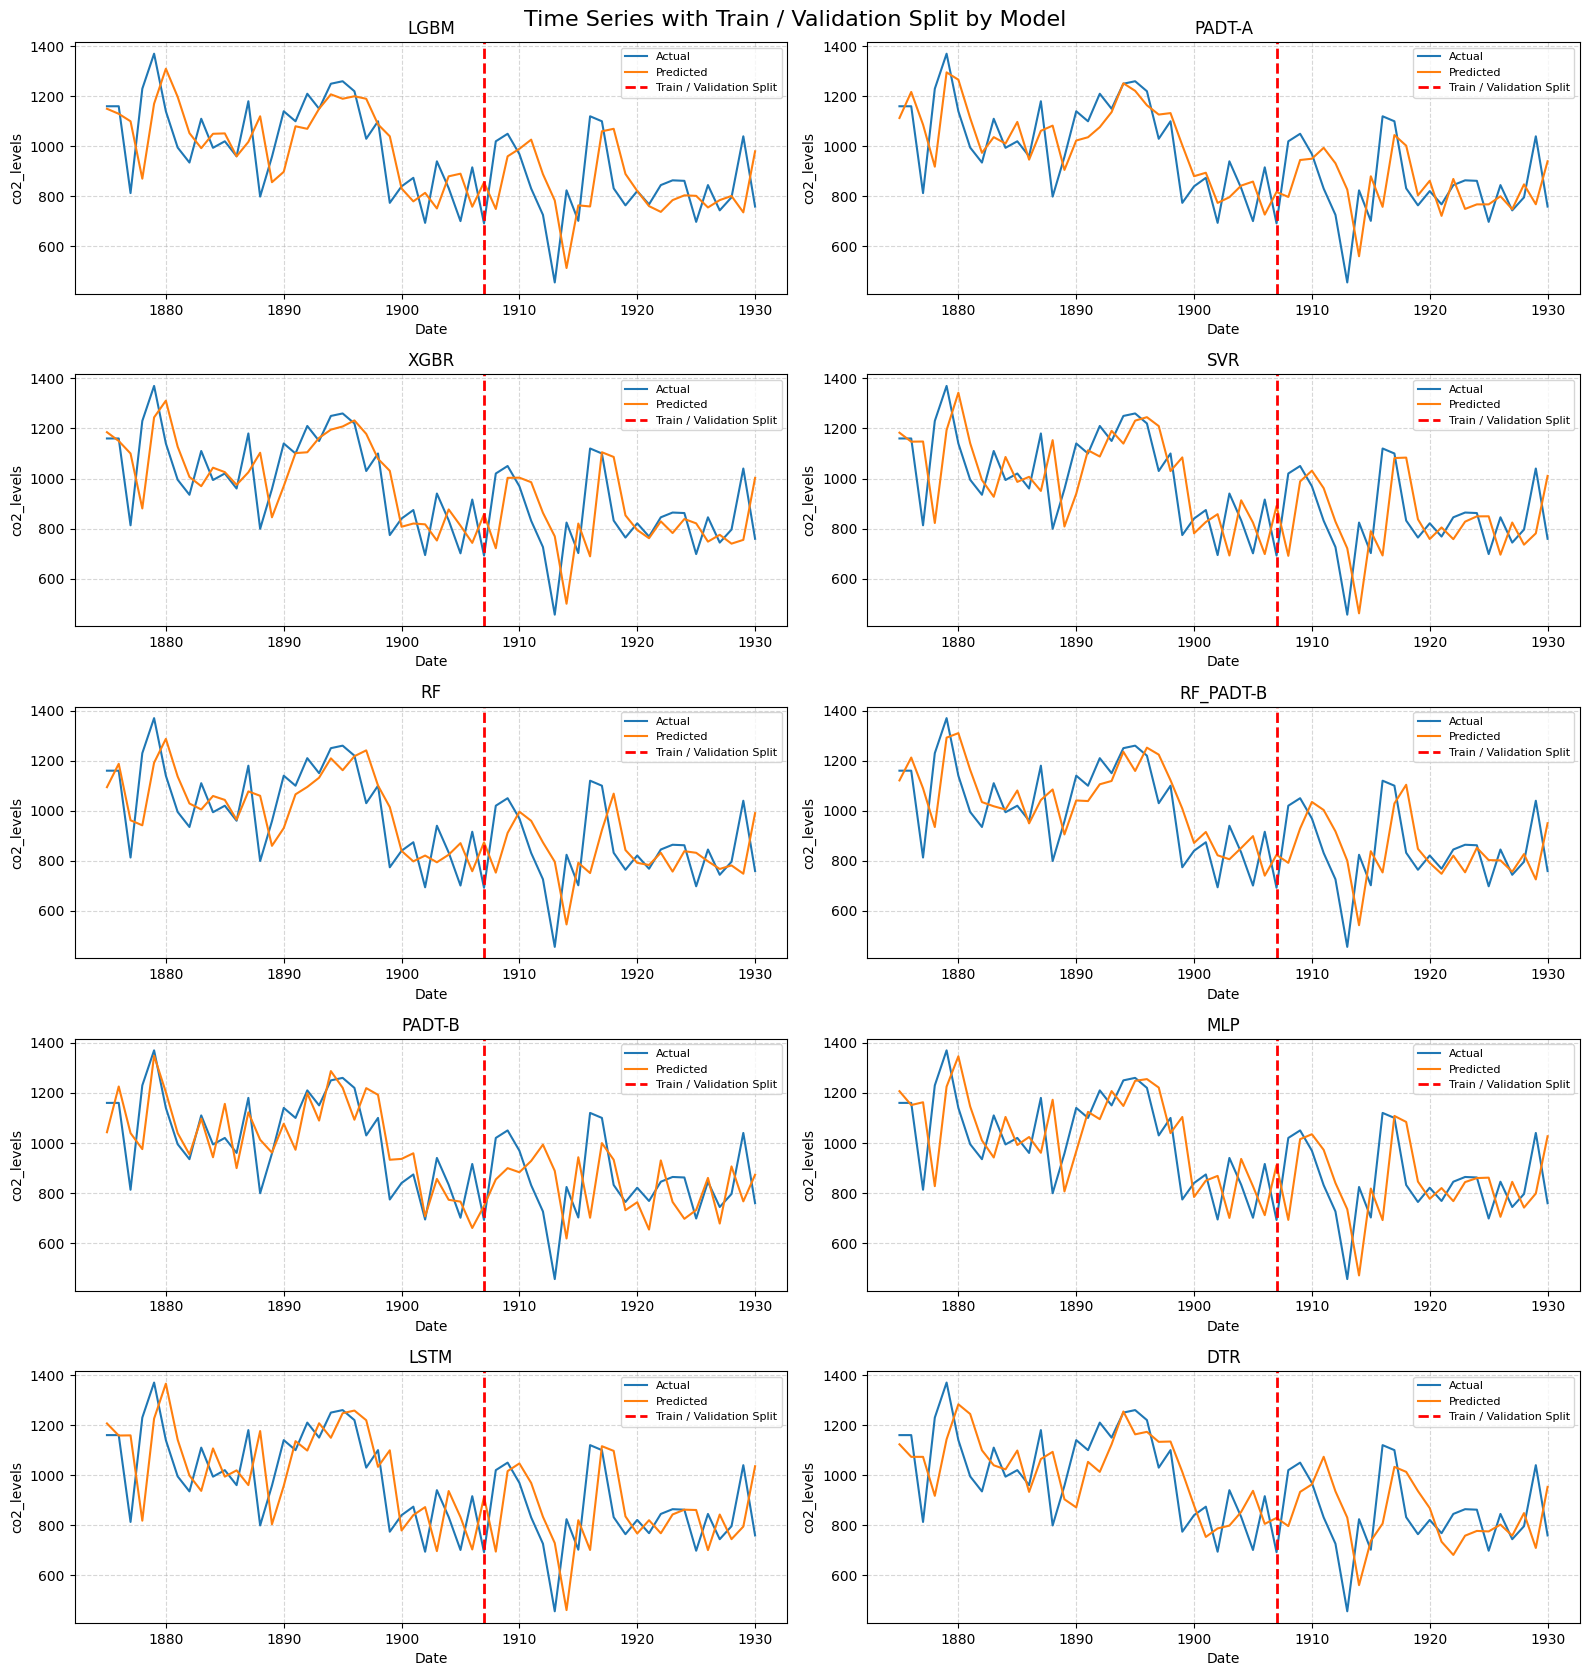

In [21]:
plot_time_series_with_split('nile')

In [17]:
def plot_actual_vs_predicted(series_name):    
    plt.figure(figsize=(10, 6))
    fig, axes = plt.subplots(6, 2, figsize=(16, 20))
    axes = axes.flatten()
    models = model_list()

    for i, name_model in enumerate(models):
            df_modelo = data_frame_a_series(name_model, series_name)
            ax = axes[i]

            ax.scatter(df_modelo[df_modelo["Phase"] == "val"]["target"], df_modelo[df_modelo["Phase"] == "val"]["pred"], alpha=0.5, label='validation', color='blue')
            ax.scatter(df_modelo[df_modelo["Phase"] == "train"]["target"], df_modelo[df_modelo["Phase"] == "train"]["pred"], alpha=0.5, label='training', color='orange')

            lims = [
                np.min([df_modelo[df_modelo["Phase"] == "val"]["target"].min(), df_modelo[df_modelo["Phase"] == "train"]["target"].min()]),
                np.max([df_modelo[df_modelo["Phase"] == "val"]["target"].max(), df_modelo[df_modelo["Phase"] == "train"]["target"].max()])
            ]
            ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Perfect Prediction')

            ax.set_xlabel('Target Value')
            ax.set_ylabel('Predicted Value')
            ax.set_title(name_model)
            ax.legend(fontsize=8)

    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f'"Time Series with Target / Predicted Split by Model {series_name}"', fontsize=16)
    plt.tight_layout()
    plt.show()




<Figure size 1000x600 with 0 Axes>

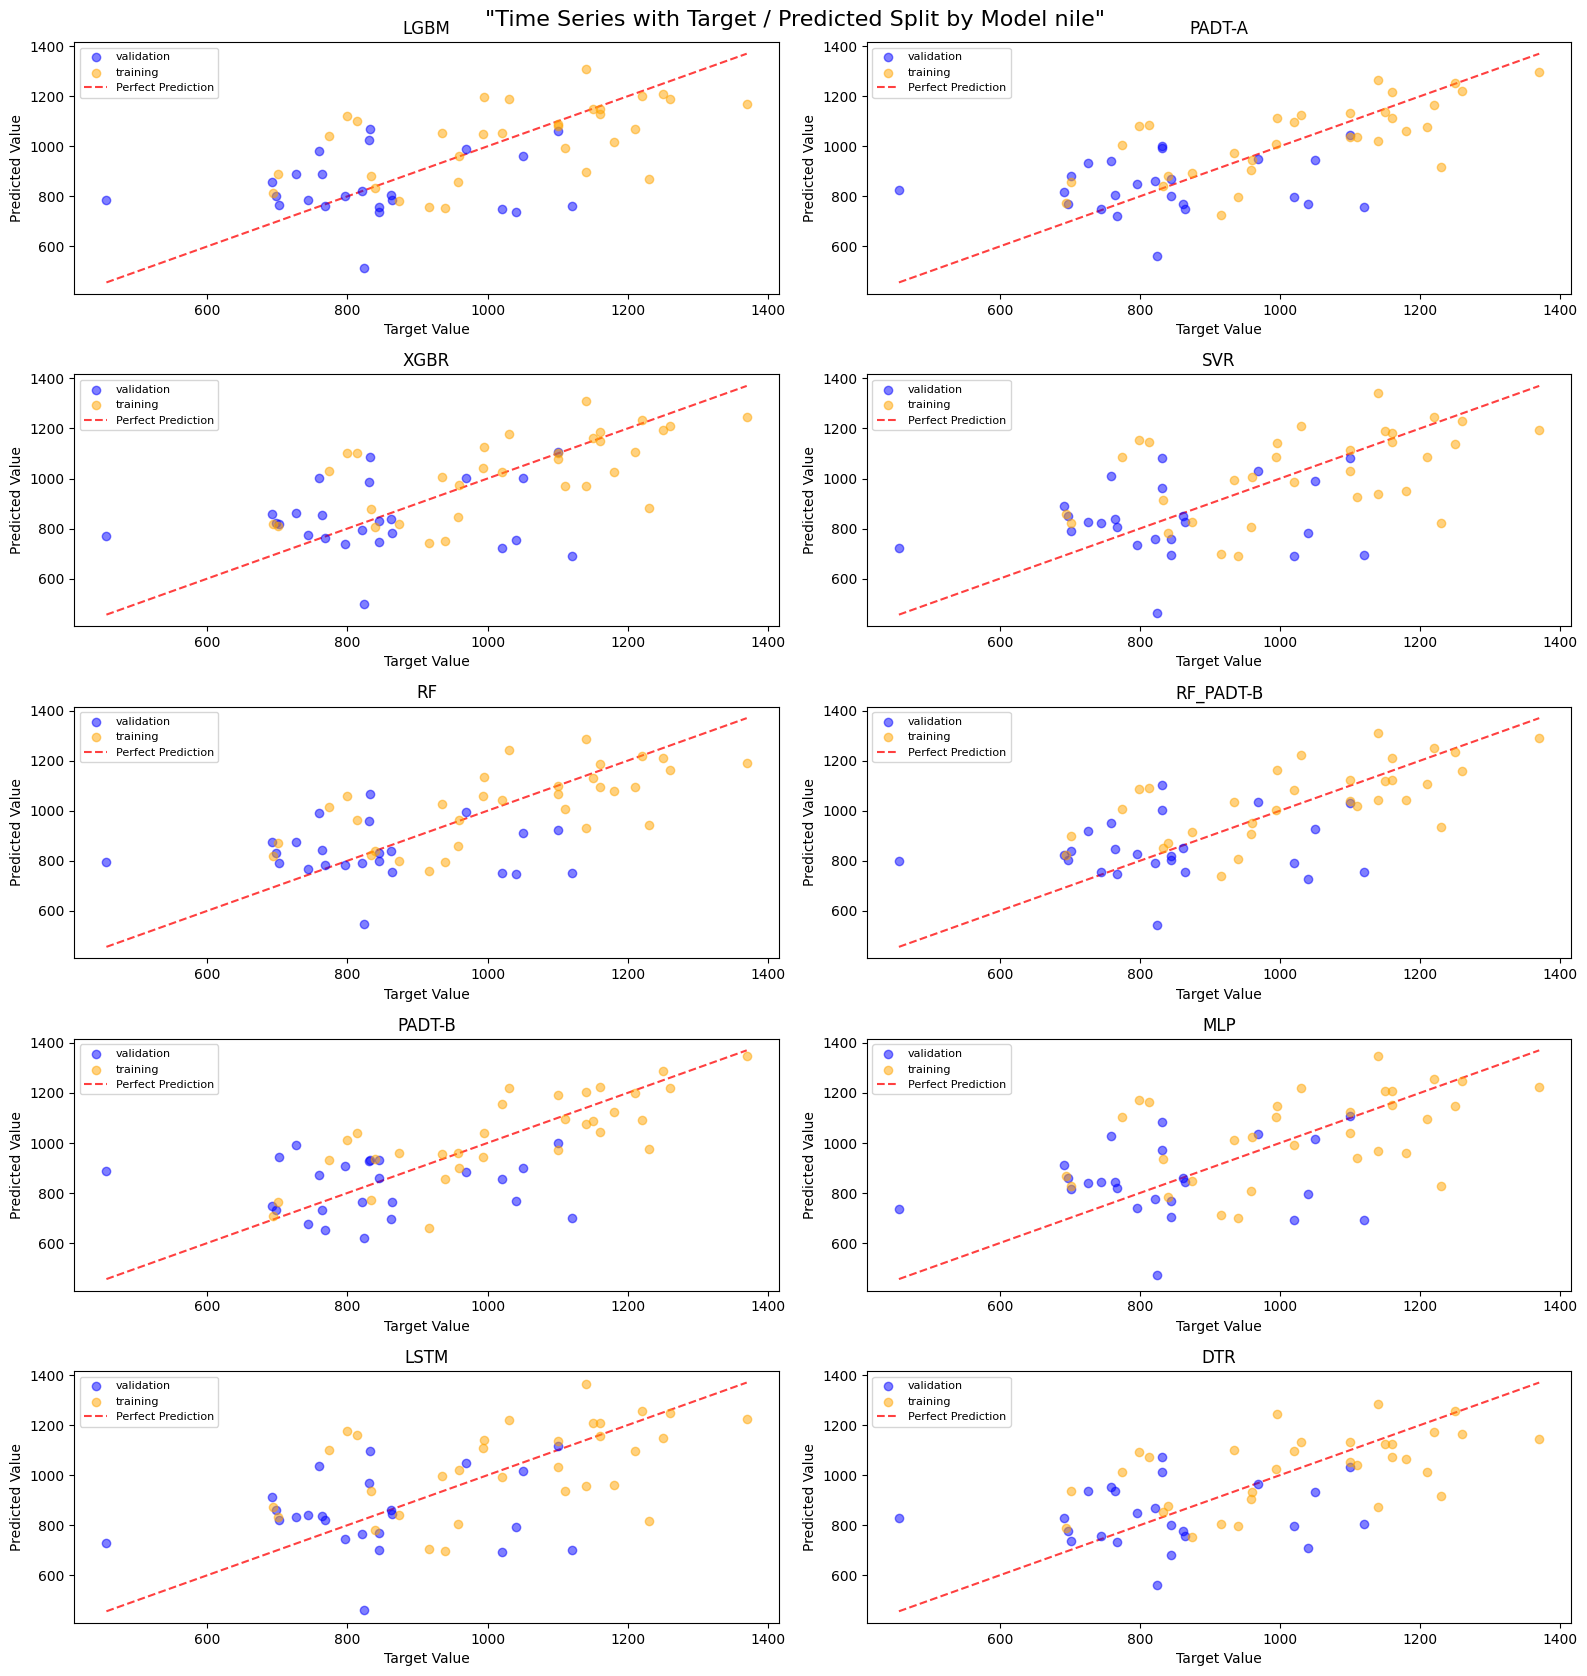

In [18]:
plot_actual_vs_predicted('nile')

In [ ]:
def plot_random_walk(series_name):
    plt.figure(figsize=(10, 6))
    fig, axes = plt.subplots(6, 2, figsize=(16, 20))
    axes = axes.flatten()
    models = model_list()
    rw_series = extract_random_walk_series()

    for i, name_model in enumerate(models):
        ax = axes[i]
        
        df_modelo = data_frame_a_series(name_model, series_name)
        date_model = date_serie(name_model, series_name)
        
        ax.plot(date_model["date"], df_modelo["target"], label="Actual", linewidth=2)
        ax.plot(date_model["date"], rw_series[series_name], label="Random Walk", linestyle="--")
        ax.plot(date_model["date"], df_modelo["pred"], label=f'{name_model}')

        ax.set_title(name_model)
        ax.set_xlabel("Date")
        ax.set_ylabel("Value")
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.5)

    for j in range(len(models), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle("Random Walk ", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_random_walk('co2_levels')


In [ ]:
'''
platagem de fronteira de decisao para SVM com kernel RBF, variando gamma e C

'''

'''
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Dados parecidos com o livro
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

def plot_decision_boundary(model, X, y, ax, title):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx0, xx1 = np.meshgrid(
        np.linspace(x0_min, x0_max, 400),
        np.linspace(x1_min, x1_max, 400)
    )

    grid = np.c_[xx0.ravel(), xx1.ravel()]
    pred = model.predict(grid).reshape(xx0.shape)

    ax.contourf(xx0, xx1, pred, alpha=0.3)
    ax.contour(xx0, xx1, pred, linewidths=1)

    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", label="Classe 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", label="Classe 1")

    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.grid(True)

configs = [
    (0.1, 0.001),
    (0.1, 1000),
    (5, 0.001),
    (5, 1000)
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (gamma, C) in zip(axes.ravel(), configs):
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", gamma=gamma, C=C)
    )

    model.fit(X, y)

    plot_decision_boundary(
        model,
        X,
        y,
        ax,
        title=f"gamma = {gamma}, C = {C}"
    )

plt.tight_layout()
plt.show()

'''

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nfrom sklearn.datasets import make_moons\nfrom sklearn.pipeline import make_pipeline\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.svm import SVC\n\n# Dados parecidos com o livro\nX, y = make_moons(n_samples=100, noise=0.15, random_state=42)\n\ndef plot_decision_boundary(model, X, y, ax, title):\n    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5\n    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5\n\n    xx0, xx1 = np.meshgrid(\n        np.linspace(x0_min, x0_max, 400),\n        np.linspace(x1_min, x1_max, 400)\n    )\n\n    grid = np.c_[xx0.ravel(), xx1.ravel()]\n    pred = model.predict(grid).reshape(xx0.shape)\n\n    ax.contourf(xx0, xx1, pred, alpha=0.3)\n    ax.contour(xx0, xx1, pred, linewidths=1)\n\n    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", label="Classe 0")\n    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", label="Classe 1")\n\n    ax.set_title(title)\n    ax.set_x